# **MAVIA — Bloom's Taxonomy Question Classifier**

## **1. Loading the Dataset and Dataset Description**

In [ ]:
#@title Install dependencies
!pip install -q scikit-learn nltk pandas joblib matplotlib seaborn datasets
!pip install -q transformers==4.51.3 accelerate>=0.21.0
!pip install -q huggingface_hub>=0.21.0
!pip uninstall -y torchaudio torchvision 2>/dev/null

import datasets.config
datasets.config.TORCHVISION_AVAILABLE = False

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
Found existing installation: torchvision 0.26.0+cpu
Uninstalling torchvision-0.26.0+cpu:
  Successfully uninstalled torchvision-0.26.0+cpu


True

In [ ]:
#@title Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import torch
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
import sklearn

print(f"scikit-learn version: {sklearn.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

scikit-learn version: 1.6.1
GPU available: False


In [ ]:
#@title Load the Bloom's Taxonomy dataset
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = '/content/drive/MyDrive/THESIS/DATASET/'

df = pd.read_csv(f"{DATA_DIR}blooms_taxonomy_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Mounted at /content/drive
Shape: (8767, 2)
Columns: ['Questions', 'Category']


,Questions,Category
0,About what proportion of the population of the...,BT1
1,Correctly label the brain lobes indicated on t...,BT1
2,Define compound interest.,BT1
3,Define four types of traceability,BT1
4,Define mercantilism.,BT1
5,"Define stream bank, floodplain and substrate.",BT1
6,Define the meaning of the Olympic Motto.,BT1
7,Draw and label a diagram of a typical stream.,BT1
8,Draw the basic outline of a page of notes usin...,BT1
9,Draw the block diagram of the central processi...,BT1


In [ ]:
#@title Inspect data types, missing values, and class distribution
QUESTION_COL = "Questions"
LABEL_COL = "Category"

print("—" * 50)
print(f"TABLE: blooms_taxonomy_dataset | Shape: {df.shape}")
print("—" * 50)
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df[LABEL_COL].value_counts())
print(f"\nUnique labels: {df[LABEL_COL].unique()}")

——————————————————————————————————————————————————
TABLE: blooms_taxonomy_dataset | Shape: (8767, 2)
——————————————————————————————————————————————————
Data Types:
Questions    object
Category     object
dtype: object

Missing Values:
Questions    0
Category     0
dtype: int64

Class distribution:
Category
BT1    2582
BT2    1801
BT3    1508
BT4    1293
BT6     800
BT5     783
Name: count, dtype: int64

Unique labels: ['BT1' 'BT2' 'BT3' 'BT4' 'BT6' 'BT5']


## **2. Data Preprocessing**

In [ ]:
#@title Map BT category codes to Bloom's Taxonomy cognitive levels
LABEL_MAP = {
    "BT1": "remember",
    "BT2": "understand",
    "BT3": "apply",
    "BT4": "analyze",
    "BT5": "evaluate",
    "BT6": "create",
}

df["bloom_level"] = df[LABEL_COL].map(LABEL_MAP)

print("Label mapping applied:")
for code, name in LABEL_MAP.items():
    count = (df[LABEL_COL] == code).sum()
    print(f"  {code} --> {name:<12} ({count} questions)")

unmapped = df["bloom_level"].isna().sum()
print(f"\nUnmapped rows: {unmapped}")

Label mapping applied:
  BT1 --> remember     (2582 questions)
  BT2 --> understand   (1801 questions)
  BT3 --> apply        (1508 questions)
  BT4 --> analyze      (1293 questions)
  BT5 --> evaluate     (783 questions)
  BT6 --> create       (800 questions)

Unmapped rows: 0


In [ ]:
#@title Remove duplicate questions
#the dataset aggregates questions from multiple sources, so duplicates exist
#duplicates leaking between train and test would inflate the evaluation scores

#normalize text for duplicate detection --> lowercase, strip punctuation, collapse whitespace
def normalize_for_dedup(text):
  text = str(text).lower().strip()
  text = re.sub(r"[^a-z0-9\s]", "", text)
  text = re.sub(r"\s+", " ", text)
  return text

df["dedup_key"] = df[QUESTION_COL].apply(normalize_for_dedup)

before = len(df)
duplicate_count = df.duplicated(subset=["dedup_key"]).sum()

#keep only the first occurrence of each duplicate group
df = df.drop_duplicates(subset=["dedup_key"], keep="first").reset_index(drop=True)

print(f"Before dedup: {before:,} questions")
print(f"Duplicates removed: {duplicate_count:,}")
print(f"After dedup:  {len(df):,} questions")
print(f"\nClass distribution after dedup:")
print(df["bloom_level"].value_counts())

Before dedup: 8,767 questions
Duplicates removed: 71
After dedup:  8,696 questions

Class distribution after dedup:
bloom_level
remember      2537
understand    1786
apply         1505
analyze       1290
create         800
evaluate       778
Name: count, dtype: int64


In [ ]:
#@title Clean and normalize question text (for TF-IDF models)
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
  text = str(text).lower().strip()
  text = re.sub(r"[^a-zA-Z0-9\s?]", "", text)
  tokens = word_tokenize(text)
  tokens = [lemmatizer.lemmatize(t) for t in tokens]
  return " ".join(tokens)

df["cleaned"] = df[QUESTION_COL].apply(preprocess_text)

#drop rows that became empty after cleaning
before_count = len(df)
df = df[df["cleaned"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)} (dropped {before_count - len(df)})")

print(f"\nSample cleaned questions:")
for _, row in df.sample(5, random_state=42).iterrows():
  print(f"  [{row['bloom_level']:<10}] {row['cleaned'][:80]}")

Rows after cleaning: 8696 (dropped 0)

Sample cleaned questions:
  [understand] whats your interpretation of that literary work ?
  [analyze   ] analyze the data on customer demographic to tailor marketing campaign
  [apply     ] analyze the ethical implication of using facial recognition technology for law e
  [create    ] formulate a new algorithm for detecting and mitigating bias in machine learning 
  [understand] illustrate two 2 implication for international advertiser


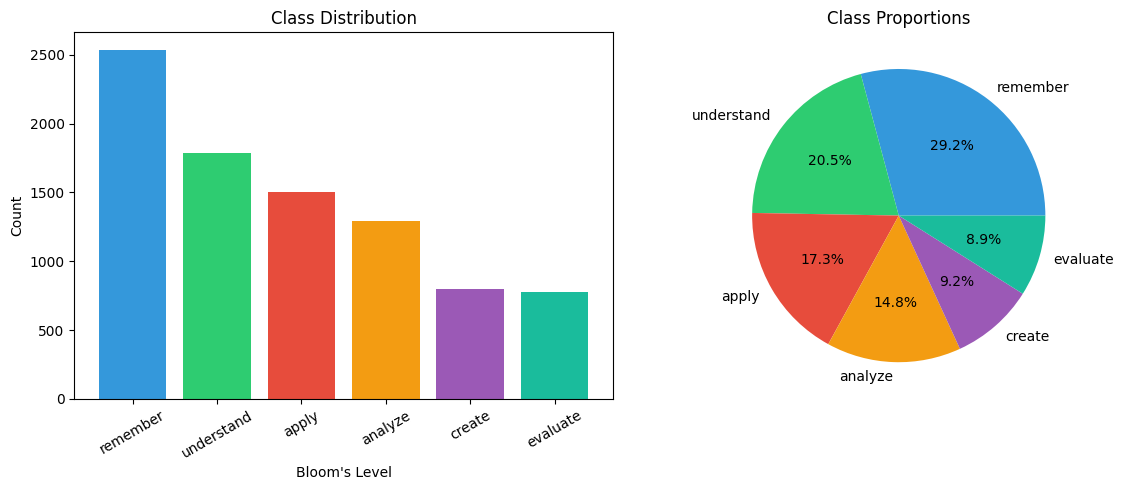

In [ ]:
#@title Visualize final class distribution
label_counts = df["bloom_level"].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel("Bloom's Level")
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Class Proportions')
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [ ]:
#@title Train-test split (80/20 stratified)
#stratified split preserves the class proportions in both sets
#all models (classical and transformer) share this same split for fair comparison
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["bloom_level"]
)

print(f"Training set: {len(train_df)} samples")
print(f"Testing set:  {len(test_df)} samples")
print(f"\nTraining distribution:")
print(train_df["bloom_level"].value_counts())
print(f"\nTesting distribution (real-world proportions preserved):")
print(test_df["bloom_level"].value_counts())

#class imbalance check --> handled via class_weight='balanced' instead of resampling
#undersampling would discard ~46% of the data; class weights keep all samples
class_counts = train_df["bloom_level"].value_counts()
print(f"\nImbalance ratio: {class_counts.max() / class_counts.min():.2f}x")
print("Handling: class_weight='balanced' (classical models) + stratification")

Training set: 6956 samples
Testing set:  1740 samples

Training distribution:
bloom_level
remember      2029
understand    1429
apply         1204
analyze       1032
create         640
evaluate       622
Name: count, dtype: int64

Testing distribution (real-world proportions preserved):
bloom_level
remember      508
understand    357
apply         301
analyze       258
create        160
evaluate      156
Name: count, dtype: int64

Imbalance ratio: 3.26x
Handling: class_weight='balanced' (classical models) + stratification


## **3. Baseline Models (Classical ML)**

In [ ]:
#@title Build TF-IDF + classifier pipelines
#the vectorizer lives INSIDE the pipeline so each CV fold fits its own vocabulary
#this prevents information from validation folds leaking into training
def make_pipeline(clf):
  return Pipeline([
      ("tfidf", TfidfVectorizer(
          max_features=5000,
          ngram_range=(1, 2),      #unigrams + bigrams
          sublinear_tf=True,
          min_df=2,
      )),
      ("clf", clf),
  ])

X_train_text = train_df["cleaned"]
y_train = train_df["bloom_level"]
X_test_text = test_df["cleaned"]
y_test = test_df["bloom_level"]

#shuffled stratified 5-fold CV
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#@title Find best SVM hyperparameters using GridSearchCV
parameter_grid = {
    'clf__C': [0.1, 0.5, 1.0, 5.0, 10.0],
    'clf__kernel': ['linear', 'rbf'],
}

total_combinations = len(parameter_grid['clf__C']) * len(parameter_grid['clf__kernel'])

print(f"Hyperparameter search space:")
print(f"  C values:   {parameter_grid['clf__C']}")
print(f"  Kernels:    {parameter_grid['clf__kernel']}")
print(f"  Total combinations: {total_combinations}")
print(f"  Cross-validation folds: 5")
print(f"  Total model fits: {total_combinations * 5}")
print(f"\nSearching...")

svm_pipeline = make_pipeline(SVC(class_weight='balanced', random_state=42))
svm_grid = GridSearchCV(svm_pipeline, parameter_grid, cv=cv_strategy,
                        scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_train_text, y_train)

print(f"Search complete.")
print(f"Best SVM parameters: {svm_grid.best_params_}")
print(f"Best CV F1: {svm_grid.best_score_:.4f}")

Hyperparameter search space:
  C values:   [0.1, 0.5, 1.0, 5.0, 10.0]
  Kernels:    ['linear', 'rbf']
  Total combinations: 10
  Cross-validation folds: 5
  Total model fits: 50

Searching...
Search complete.
Best SVM parameters: {'clf__C': 1.0, 'clf__kernel': 'rbf'}
Best CV F1: 0.7809


In [ ]:
#@title Train and evaluate the classical models
classical_models = {
    "SVM": make_pipeline(SVC(
        C=svm_grid.best_params_['clf__C'],
        kernel=svm_grid.best_params_['clf__kernel'],
        class_weight='balanced',
        random_state=42
    )),
    "Logistic Regression": make_pipeline(LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    )),
    "Naive Bayes": make_pipeline(MultinomialNB(alpha=1.0)),
}

results = {}

for name, pipeline in classical_models.items():
  print(f"\n{'—' * 50}")
  print(f"Training: {name}")
  print('—' * 50)

  pipeline.fit(X_train_text, y_train)
  y_pred = pipeline.predict(X_test_text)

  test_acc = accuracy_score(y_test, y_pred)
  test_f1 = f1_score(y_test, y_pred, average='weighted')

  print(classification_report(y_test, y_pred))

  cv_scores = cross_val_score(pipeline, X_train_text, y_train,
                              cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
  print(f"5-Fold CV F1 (weighted): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

  results[name] = {
      "test_acc": test_acc,
      "test_f1": test_f1,
      "cv_mean": cv_scores.mean(),
      "cv_std": cv_scores.std(),
      "y_pred": list(y_pred),
      "y_true": list(y_test),
  }


——————————————————————————————————————————————————
Training: SVM
——————————————————————————————————————————————————
              precision    recall  f1-score   support

     analyze       0.80      0.68      0.73       258
       apply       0.80      0.81      0.81       301
      create       0.91      0.92      0.91       160
    evaluate       0.93      0.81      0.86       156
    remember       0.74      0.81      0.77       508
  understand       0.68      0.68      0.68       357

    accuracy                           0.77      1740
   macro avg       0.81      0.78      0.79      1740
weighted avg       0.78      0.77      0.77      1740

5-Fold CV F1 (weighted): 0.7809 ± 0.0060

——————————————————————————————————————————————————
Training: Logistic Regression
——————————————————————————————————————————————————
              precision    recall  f1-score   support

     analyze       0.71      0.69      0.70       258
       apply       0.79      0.77      0.78       301
   

## **4. Model Building (Transformer Fine-Tuning)**

In [ ]:
#@title Prepare data for transformer fine-tuning
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from datasets import Dataset

#label encoding
label_names = sorted(df["bloom_level"].unique())
label2id = {label: i for i, label in enumerate(label_names)}
id2label = {i: label for label, i in label2id.items()}
print(f"Labels: {label2id}")

#transformers use RAW question text --> they have their own subword tokenizer
#over-cleaning (lemmatization etc.) removes information they can use
base_train = Dataset.from_dict({
    "text": train_df[QUESTION_COL].tolist(),
    "label": [label2id[l] for l in train_df["bloom_level"]],
})
base_test = Dataset.from_dict({
    "text": test_df[QUESTION_COL].tolist(),
    "label": [label2id[l] for l in test_df["bloom_level"]],
})

#split train further into train/validation for early stopping
train_val = base_train.train_test_split(test_size=0.1, seed=42)
print(f"Train: {len(train_val['train'])} | Validation: {len(train_val['test'])} | Test: {len(base_test)}")

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=-1)
  return {
      "accuracy": accuracy_score(labels, preds),
      "f1_weighted": f1_score(labels, preds, average="weighted"),
      "f1_macro": f1_score(labels, preds, average="macro"),
  }

Labels: {'analyze': 0, 'apply': 1, 'create': 2, 'evaluate': 3, 'remember': 4, 'understand': 5}
Train: 6260 | Validation: 696 | Test: 1740


In [ ]:
#@title Fine-tuning function (reused for both transformer models)
def finetune_transformer(model_name, display_name, batch_size=16):
  print(f"\n{'—' * 50}")
  print(f"Fine-tuning: {display_name} ({model_name})")
  print('—' * 50)

  tokenizer = AutoTokenizer.from_pretrained(model_name)

  def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=128)

  train_hf = train_val["train"].map(tokenize_fn, batched=True)
  val_hf = train_val["test"].map(tokenize_fn, batched=True)
  test_hf = base_test.map(tokenize_fn, batched=True)

  for ds in (train_hf, val_hf, test_hf):
    ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

  model = AutoModelForSequenceClassification.from_pretrained(
      model_name,
      num_labels=len(label_names),
      id2label=id2label,
      label2id=label2id,
  )

  training_args = TrainingArguments(
      output_dir=f"./{display_name.lower()}_blooms",
      num_train_epochs=10,
      per_device_train_batch_size=batch_size,
      per_device_eval_batch_size=64,
      learning_rate=2e-5,
      weight_decay=0.01,
      warmup_ratio=0.1,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
      metric_for_best_model="f1_weighted",
      logging_steps=50,
      report_to="none",
      seed=42,
  )

  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=train_hf,
      eval_dataset=val_hf,
      compute_metrics=compute_metrics,
      callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
  )

  trainer.train()

  #evaluate on the held-out test set
  test_output = trainer.predict(test_hf)
  pred_ids = np.argmax(test_output.predictions, axis=-1)
  preds = [id2label[i] for i in pred_ids]
  true = [id2label[i] for i in test_output.label_ids]

  test_acc = accuracy_score(true, preds)
  test_f1 = f1_score(true, preds, average='weighted')

  print(f"\n{display_name} Classification Report:")
  print(classification_report(true, preds))

  results[display_name] = {
      "test_acc": test_acc,
      "test_f1": test_f1,
      "cv_mean": None,
      "cv_std": None,
      "y_pred": preds,
      "y_true": true,
  }

  return trainer, tokenizer

In [ ]:
#@title Fine-tune DistilBERT
distilbert_trainer, distilbert_tokenizer = finetune_transformer(
    "distilbert-base-uncased", "DistilBERT", batch_size=32
)


——————————————————————————————————————————————————
Fine-tuning: DistilBERT (distilbert-base-uncased)
——————————————————————————————————————————————————


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/696 [00:00<?, ? examples/s]

Map:   0%|          | 0/1740 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
#@title Fine-tune RoBERTa
roberta_trainer, roberta_tokenizer = finetune_transformer(
    "roberta-base", "RoBERTa", batch_size=16
)

## **5. Test and Validation**

In [ ]:
#@title Model comparison table
print(f"\n{'Model':<22} {'Test Acc':<12} {'Test F1 (w)':<14} {'CV F1':<20}")
print("=" * 68)
for name, res in results.items():
  cv_str = f"{res['cv_mean']:.4f} ± {res['cv_std']:.4f}" if res['cv_mean'] else "—"
  print(f"{name:<22} {res['test_acc']:.4f}{'':6} {res['test_f1']:.4f}{'':8} {cv_str}")

best_model_name = max(results, key=lambda k: results[k]["test_f1"])
print(f"\n>>> Best model: {best_model_name} (Test F1: {results[best_model_name]['test_f1']:.4f})")

In [ ]:
#@title Confusion matrices for all models
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5))

for ax, (name, res) in zip(axes, results.items()):
  cm = confusion_matrix(res["y_true"], res["y_pred"], labels=label_names)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
  disp.plot(cmap='Blues', ax=ax, colorbar=False)
  ax.set_title(f'{name}\n(Acc: {res["test_acc"]:.4f})')
  ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("all_confusion_matrices.png", dpi=150)
plt.show()

In [ ]:
#@title Per-class F1 comparison (best classical vs best transformer)
best_classical = max((k for k in classical_models), key=lambda k: results[k]["test_f1"])
best_transformer = max((k for k in results if k not in classical_models),
                       key=lambda k: results[k]["test_f1"])

classical_report = classification_report(
    results[best_classical]["y_true"], results[best_classical]["y_pred"], output_dict=True)
transformer_report = classification_report(
    results[best_transformer]["y_true"], results[best_transformer]["y_pred"], output_dict=True)

x = np.arange(len(label_names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, [classical_report[c]["f1-score"] for c in label_names],
        width, label=best_classical, color='#3498db')
plt.bar(x + width/2, [transformer_report[c]["f1-score"] for c in label_names],
        width, label=best_transformer, color='#e74c3c')
plt.xticks(x, label_names, rotation=30)
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.title(f'Per-Class F1: {best_classical} vs {best_transformer}')
plt.legend()
plt.tight_layout()
plt.savefig("per_class_f1_comparison.png", dpi=150)
plt.show()

In [ ]:
#@title Difficulty-level evaluation (3-class: the label MAVIA consumes)
#the adaptive system maps Bloom's levels into three difficulty tiers:
#  remember + understand --> easy
#  apply + analyze       --> medium
#  evaluate + create     --> hard
#residual model confusion occurs mostly between ADJACENT Bloom's levels
#that map to the SAME difficulty tier, so operational accuracy is higher
BLOOM_TO_DIFFICULTY = {
    "remember": "easy", "understand": "easy",
    "apply": "medium", "analyze": "medium",
    "evaluate": "hard", "create": "hard",
}

best_res = results[best_model_name]
true_difficulty = [BLOOM_TO_DIFFICULTY[l] for l in best_res["y_true"]]
pred_difficulty = [BLOOM_TO_DIFFICULTY[l] for l in best_res["y_pred"]]

diff_acc = accuracy_score(true_difficulty, pred_difficulty)
diff_f1 = f1_score(true_difficulty, pred_difficulty, average='weighted')

print("—" * 55)
print(f"DIFFICULTY-LEVEL EVALUATION ({best_model_name})")
print("—" * 55)
print(f"Accuracy:      {diff_acc:.4f}")
print(f"F1 (weighted): {diff_f1:.4f}\n")
print(classification_report(true_difficulty, pred_difficulty))

diff_labels = ["easy", "medium", "hard"]
cm = confusion_matrix(true_difficulty, pred_difficulty, labels=diff_labels)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=diff_labels)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title(f'Difficulty-Level Confusion Matrix (Acc: {diff_acc:.4f})')
plt.tight_layout()
plt.savefig("difficulty_confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
#@title Model summary
print("—" * 55)
print(f"MAVIA Bloom's Classifier Summary")
print("—" * 55)
print(f"Dataset (after dedup):   {len(df):,} questions")
print(f"Train / Test:            {len(train_df):,} / {len(test_df):,} (80/20 stratified)")
print(f"Best model:              {best_model_name}")
print(f"Bloom's (6-class) acc:   {results[best_model_name]['test_acc']:.4f}")
print(f"Bloom's (6-class) F1:    {results[best_model_name]['test_f1']:.4f}")
print(f"Difficulty (3-class) acc:{diff_acc:.4f}")
print(f"Difficulty (3-class) F1: {diff_f1:.4f}")
print(f"Best SVM parameters:     {svm_grid.best_params_}")
print(f"scikit-learn version:    {sklearn.__version__}")
print("—" * 55)

## **6. Export Models**

In [ ]:
#@title Export the best transformer model (for the Django backend)
import shutil

SAVE_DIR = "roberta_blooms_final"
roberta_trainer.save_model(SAVE_DIR)
roberta_tokenizer.save_pretrained(SAVE_DIR)

shutil.make_archive("roberta_blooms_final", "zip", SAVE_DIR)
print(f"Saved and zipped: roberta_blooms_final.zip")

#backup to Drive
!cp roberta_blooms_final.zip "{DATA_DIR}"
print(f"Backup copied to Drive: {DATA_DIR}roberta_blooms_final.zip")

In [ ]:
#@title Export SVM pipeline (lightweight fallback)
#note: evaluation scores above come from the held-out split;
#the deployment copy is refit on the full dataset to use all available data
best_svm_pipeline = classical_models["SVM"]
best_svm_pipeline.fit(df["cleaned"], df["bloom_level"])

joblib.dump(best_svm_pipeline, "bloom_svm_pipeline.joblib")
print("Saved: bloom_svm_pipeline.joblib (tfidf + svm bundled in one file)")
print(f"\nMatch this version in the Django venv:")
print(f"  pip install scikit-learn=={sklearn.__version__}")

In [ ]:
#@title Sanity test on sample questions
test_questions = [
    "What is the water cycle?",
    "Explain why evaporation is important for the water cycle",
    "If a lake is located in a hot desert, what would happen to its water level over time?",
    "Compare the inner and outer planets of the solar system",
    "Which stage of the water cycle is most critical for agriculture? Justify your answer.",
    "Design an experiment to show how condensation forms clouds",
]

print("SVM pipeline predictions:")
for q in test_questions:
  pred = best_svm_pipeline.predict([preprocess_text(q)])[0]
  print(f"  [{pred:<10}] {q}")

print("\nRoBERTa predictions:")
device = "cuda" if torch.cuda.is_available() else "cpu"
roberta_model = roberta_trainer.model.to(device)
roberta_model.eval()
for q in test_questions:
  inputs = roberta_tokenizer(q, return_tensors="pt", truncation=True,
                             padding=True, max_length=128).to(device)
  with torch.no_grad():
    logits = roberta_model(**inputs).logits
  pred = id2label[int(logits.argmax())]
  print(f"  [{pred:<10}] {q}")

In [ ]:
#@title Download everything
from google.colab import files

files.download("roberta_blooms_final.zip")
files.download("bloom_svm_pipeline.joblib")
files.download("all_confusion_matrices.png")
files.download("per_class_f1_comparison.png")
files.download("difficulty_confusion_matrix.png")
files.download("class_distribution.png")